In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [1]:
using_colab = True

In [4]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 109.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-8cn267no
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-8cn267no
  Resolved https://github.com/facebookresearch/sam3.git to commit 8e451d5eb43c817b64ae7577fb7b9ae223db88a9
  Installing 

In [2]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [11]:
!git clone https://github.com/facebookresearch/sam3.git
!cd sam3
!pip install -e ".[notebooks]"

fatal: destination path 'sam3' already exists and is not an empty directory.
Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor


sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [28]:
# load model
model = build_sam3_image_model()
processor = Sam3Processor(model)

In [29]:
!ls

sam3  sample_data


In [52]:
# load the image
image_path = f"sam3/assets/images/ee2.png"
image = Image.open(image_path).convert("RGB")
inference_state = processor.set_image(image)

In [53]:
# import plotting utils to display result
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

In [54]:
# make inference
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="grey icon dot box")


In [55]:

if 'scores' in inference_state and inference_state['scores'] is not None and len(inference_state['scores']) > 0:
    # Safely convert to a PyTorch tensor
    scores_tensor = torch.as_tensor(inference_state['scores'])
    best_idx = torch.argmax(scores_tensor).item()  # Returns index of the absolute highest score
else:
    best_idx = 0  # Default fallback if empty

# 2. Slice keys safely using the correct index range
target_keys = ['masks', 'boxes', 'scores', 'masks_logits']

for key in target_keys:
    if key in inference_state and inference_state[key] is not None and len(inference_state[key]) > 0:
        # Using [best_idx : best_idx + 1] cleanly preserves the model tensor dimensions
        inference_state[key] = inference_state[key][best_idx : best_idx + 1]

found 1 object(s)


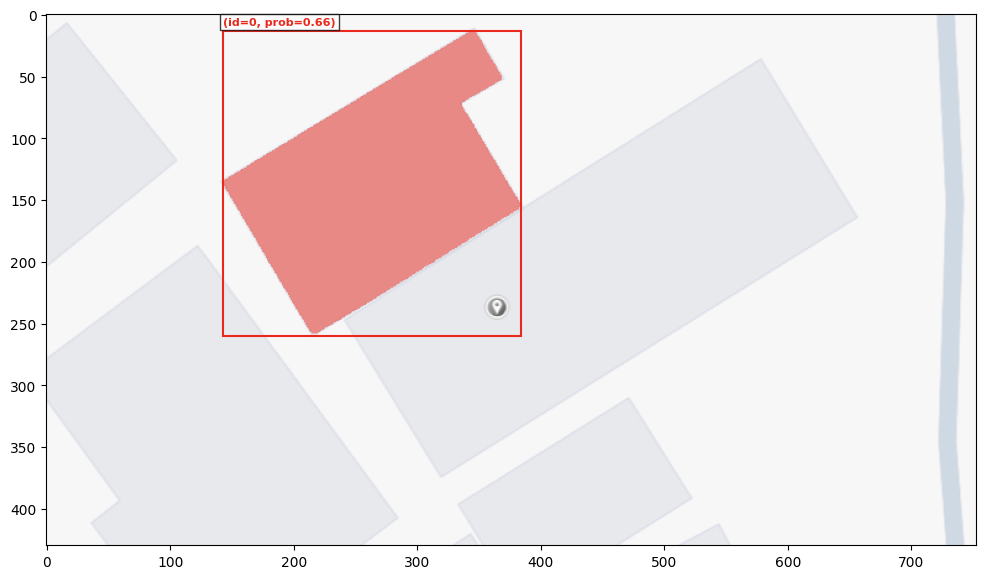

In [56]:

# plot result
img0 = Image.open(image_path)
plot_results(img0, inference_state)

Ignore the cells below. They are just for converting png to jpb